### Importing modules, loading the dataset and EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
penguins_df = pd.read_csv(r"C:\Users\Apoorva Goel\OneDrive\Desktop\Projects\clustering_penguins\penguins.csv")

In [3]:
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [7]:
# statistical properties of the dataframe indicate no outliers
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904
std,5.452462,1.960275,14.035971,806.361278
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.700000,17.300000,197.000000,4025.000000
75%,48.625000,18.700000,213.000000,4781.250000
max,59.600000,21.500000,231.000000,6300.000000


In [9]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


In [11]:
# no missing values
penguins_df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

### Preprocessing for the ML model

In [14]:
penguins_df.columns.to_list()

['culmen_length_mm',
 'culmen_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [16]:
numeric_columns = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']
#scale only the numeric columns
scaler = StandardScaler()
penguins_scaled_num = scaler.fit_transform(penguins_df[numeric_columns])
penguins_scaled_df = pd.DataFrame(penguins_scaled_num, columns= numeric_columns)
# do one-hot-encoding for the gender column 
sex_encoded = pd.get_dummies(penguins_df['sex'], drop_first=True, dtype=int)
#combine the two 
X_train  = pd.concat([penguins_scaled_df, sex_encoded], axis=1)

In [18]:
X_train.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,MALE
0,-0.903906,0.790360,-1.425342,-0.566948,1
1,-0.830434,0.126187,-1.068577,-0.504847,0
2,-0.683490,0.432728,-0.426399,-1.187953,0
3,-1.344738,1.096901,-0.569105,-0.939551,0
4,-0.867170,1.761074,-0.783164,-0.691149,1


### Training the Model

### finding the optimal k

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

Text(0, 0.5, 'Inertia')

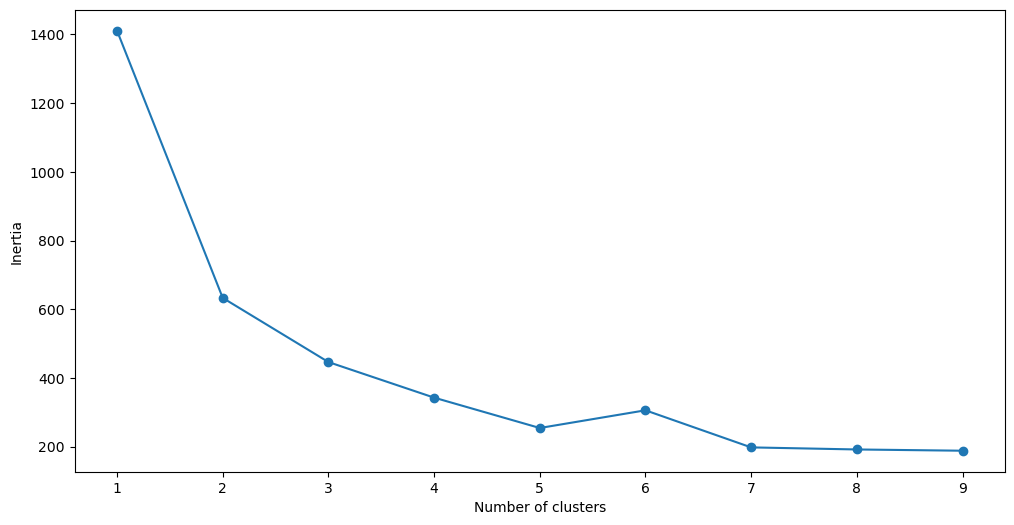

In [21]:
#fitting multiple k-means algorithms and storing values in an empty list 
SSE =[]
for cluster in range(1,10):
    model = KMeans(n_clusters = cluster, init = 'k-means++')
    model.fit(X_train)
    SSE.append(model.inertia_)

#converting the results into a dataframe and plotting it 
frame = pd.DataFrame({'Cluster':range(1,10), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [23]:
# training a model for k=3 and k=4 to comapre
kmeans_3 = KMeans(n_clusters=3, init = 'k-means++')
labels_k3 = kmeans_3.fit_predict(X_train)

kmeans_4 = KMeans(n_clusters=4, init = 'k-means++')
labels_k4 = kmeans_4.fit_predict(X_train)

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [25]:
frame3 = pd.DataFrame(X_train)
frame3['cluster'] = labels_k3
frame3['cluster'].value_counts()

cluster
1    212
2     62
0     58
Name: count, dtype: int64

In [27]:
frame4 = pd.DataFrame(X_train)
frame4['cluster'] = labels_k4
frame4['cluster'].value_counts()

cluster
0    119
2     81
1     69
3     63
Name: count, dtype: int64

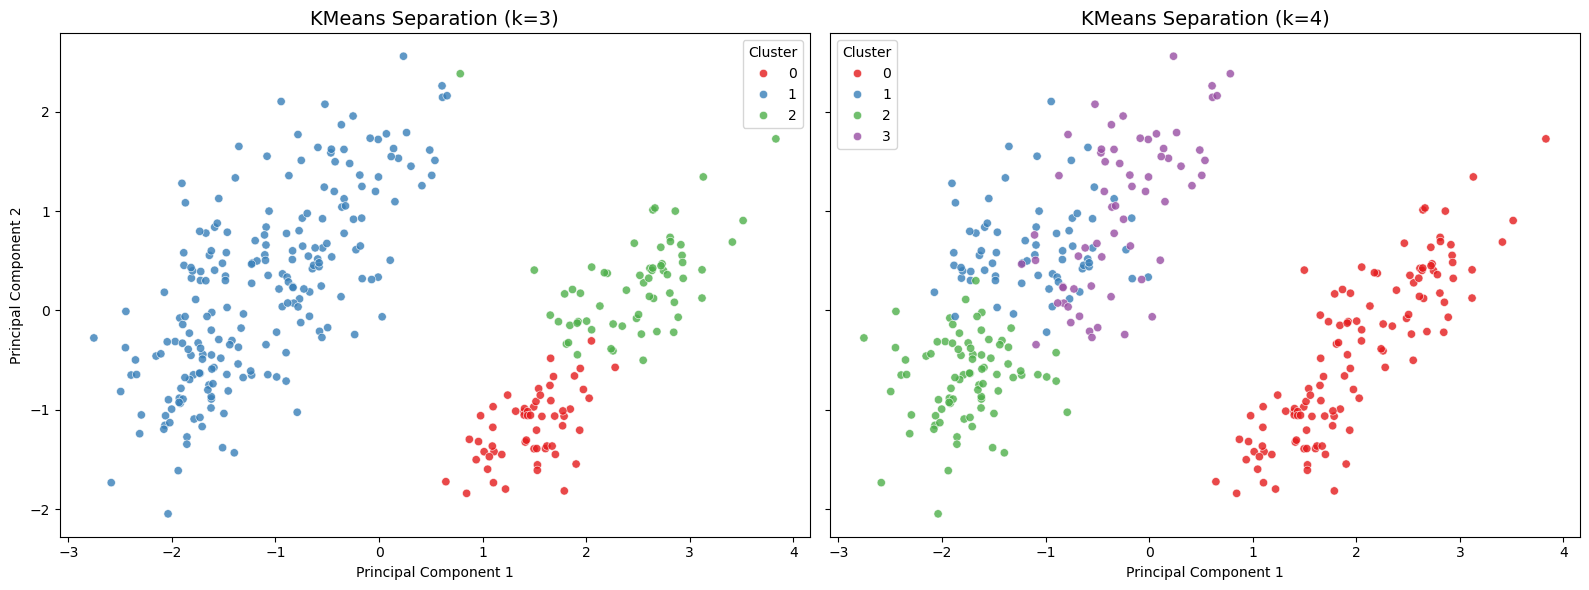

In [29]:
# after plotting k=3 and k=4 we can see that when we try to create 4 clusters it is just
#slicing the cluster into 2 and there is no organic isolation that could be capturing a real pattern
# so k=3 seems like the best option

# 1. Apply PCA to reduce X_train to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

# 2. Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Plot for k=3
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=labels_k3, palette='Set1', 
    alpha=0.8, ax=axes[0]
)
axes[0].set_title('KMeans Separation (k=3)', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(title='Cluster')

# Plot for k=4
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=labels_k4, palette='Set1', 
    alpha=0.8, ax=axes[1]
)
axes[1].set_title('KMeans Separation (k=4)', fontsize=14)
axes[1].set_xlabel('Principal Component 1')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

In [31]:
#creating a statistical df for each cluster when k=3

# 2. Add the k=3 cluster labels back to your original unscaled dataframe
penguins_df['label'] = labels_k3

# 3. Aggregate the numeric columns by cluster to compute the means
stat_penguins = penguins_df.groupby('label')[numeric_columns].mean()

# Display the final characteristic table
print("--- Final Cluster Characteristics (k=3 Means) ---")
display(stat_penguins)

--- Final Cluster Characteristics (k=3 Means) ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,45.563793,14.237931,212.706897,4679.741379
1,41.992453,18.346698,191.806604,3706.367925
2,49.514516,15.798387,221.354839,5473.790323
